In [ ]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 11.8 MB/s eta 0:00:00


In [ ]:
# Carga de librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score
import phik
from phik.report import plot_correlation_matrix


In [ ]:
# Carga de datos
from google.colab import files
import io
archivo_subido = files.upload()
nombre_archivo = next(iter(archivo_subido))

Saving RawData_HSBC_prueba.xlsx to RawData_HSBC_prueba (2).xlsx


In [ ]:
# Limpieza y estandarizacion

df_data = pd.read_excel(io.BytesIO(archivo_subido[nombre_archivo]), sheet_name='Dataset')
df_data.columns = df_data.columns.str.strip().str.lower().str.replace(' ', '_')
df_data = df_data.rename(columns={
    'ocupation': 'occupation',
    'ocupation.1': 'occupation_id',
    'ernings_flag': 'earnings_flag',
    'ernings_flag.1': 'earnings_flag_id'
})
columnas_id = [col for col in df_data.columns if col.endswith('.1')]
df_data_explor = df_data.drop(columns=columnas_id).copy()
df_data_explor.replace('?', np.nan, inplace=True)

# cantidad de valores nulos
print("Valores nulos (por columna):")
print(df_data_explor.isnull().sum())

columnas_categoricas = df_data_explor.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    df_data_explor[col] = df_data_explor[col].astype('category')

print("\nInformación del DataFrame limpio:")
#df_data_explor.info()
df_data_explor.head()


Valores nulos (por columna):
age_of_client                   0
type_of_work                 1836
fnlwgt                          0
education_level                 0
num_of_years_of_education       0
marital_status                  0
occupation                   1843
occupation_id                   0
type_of_relationship            0
type_of_race                    0
sex                            18
capital_gain                    0
capital_loss                    0
hours_of_work_per_week          0
native_country                583
earnings_flag                   0
earnings_flag_id                0
dtype: int64

Información del DataFrame limpio:


,age_of_client,type_of_work,fnlwgt,education_level,num_of_years_of_education,marital_status,occupation,occupation_id,type_of_relationship,type_of_race,sex,capital_gain,capital_loss,hours_of_work_per_week,native_country,earnings_flag,earnings_flag_id
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,34,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,35,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,36,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,36,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,37,Wife,Black,Female,0,0,40,Cuba,<=50K,0


Analisis exploratorio de datos (simple)

Suma Final Weight (Población total estimada): 6,179,373,392

Total de personas (filas en dataset): 32,561
 # ingresos >50k: 7,841
 # ingresos <=50k: 24,720
Porcentaje # con ingresos >50k: 24.08%


PORCENTAJE DE PERSONAS QUE GANAN >50K POR CATEGORÍA
Variable: TYPE OF WORK
type_of_work
Self-emp-inc        55.734767
Federal-gov         38.645833
Local-gov           29.479216
Self-emp-not-inc    28.492719
State-gov           27.195686
Private             21.867289
Never-worked         0.000000
Without-pay          0.000000
Name: earnings_flag_id, dtype: float64
----------------------------------------
Variable: EDUCATION LEVEL
education_level
Doctorate       74.092010
Prof-school     73.437500
Masters         55.658735
Bachelors       41.475257
Assoc-voc       26.121563
Assoc-acdm      24.835989
Some-college    19.023454
HS-grad         15.950862
12th             7.621247
10th             6.645230
Name: earnings_flag_id, dtype: float64
----------------------------------------
Variable: MAR

/tmp/ipykernel_2130/2411836416.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_data_explor.groupby(col)['earnings_flag_id'].mean().sort_values(ascending=False) * 100


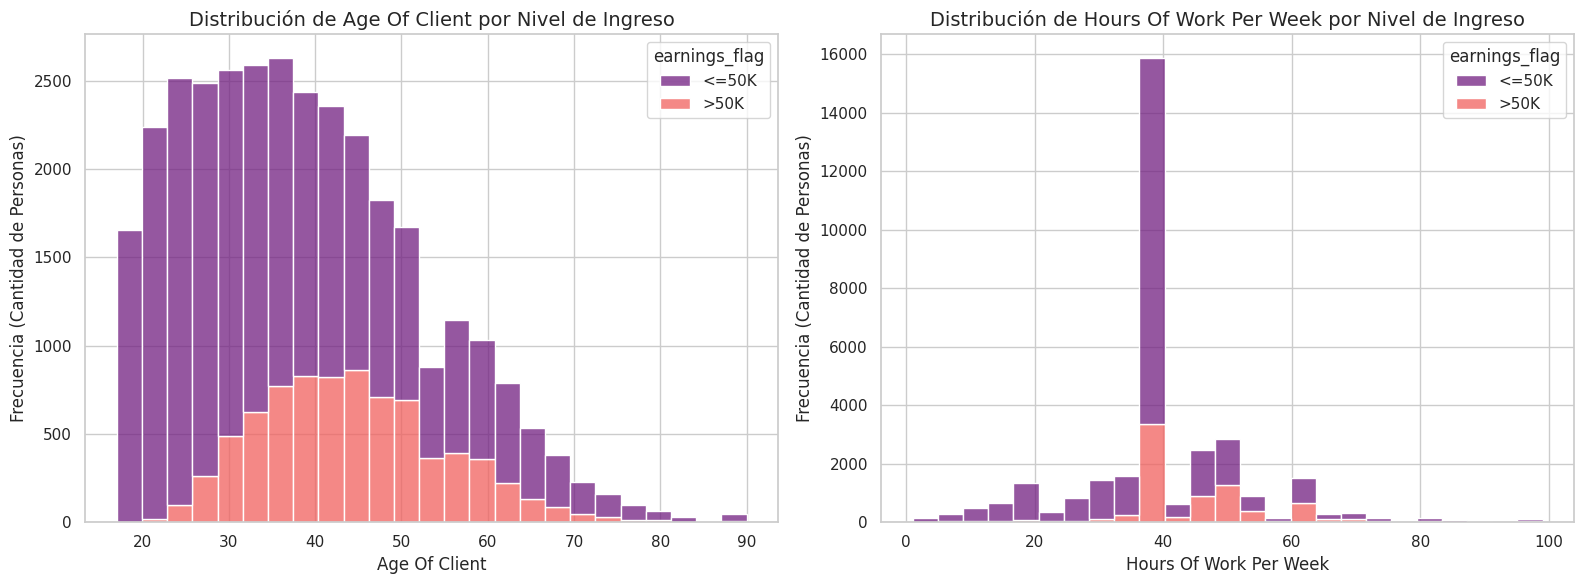

In [ ]:
# fnlwgt = 'number of units in the target population'
# Es el numero de personas representadas por esta entrada, en un censo
# Total fnlwgt
print(f"Suma Final Weight (Población total estimada): {df_data_explor['fnlwgt'].sum():,}\n")

# Calculamos los totales usando el ID (1 = >50K, 0 = <=50K)
menor_50k = (df_data_explor['earnings_flag_id'] == 0).sum()
mayor_50k = (df_data_explor['earnings_flag_id'] == 1).sum()
total_personas = menor_50k + mayor_50k

print(f"Total de personas (filas en dataset): {total_personas:,}")
print(f" # ingresos >50k: {mayor_50k:,}")
print(f" # ingresos <=50k: {menor_50k:,}")
print(f"Porcentaje # con ingresos >50k: {mayor_50k / total_personas * 100:.2f}%\n")


cols_categoricas = [
    'type_of_work',
    'education_level',
    'marital_status',
    'type_of_relationship',
    'sex',
    'native_country'
]
print("")
print("PORCENTAJE DE PERSONAS QUE GANAN >50K POR CATEGORÍA")
for col in cols_categoricas:
    stats = df_data_explor.groupby(col)['earnings_flag_id'].mean().sort_values(ascending=False) * 100
    stats = stats.dropna()

    print(f"Variable: {col.replace('_', ' ').upper()}")
    print(stats.head(10)) # Top 10
    print("-" * 40)


cols_numericas = ['age_of_client', 'hours_of_work_per_week']
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(cols_numericas):
    sns.histplot(
        data=df_data_explor,
        x=col,
        hue='earnings_flag',
        multiple="stack",
        palette="magma",
        bins=25,
        ax=axes[i]
    )

    # Formato
    titulo = col.replace('_', ' ').title()
    axes[i].set_title(f'Distribución de {titulo} por Nivel de Ingreso', fontsize=14)
    axes[i].set_xlabel(titulo, fontsize=12)
    axes[i].set_ylabel('Frecuencia (Cantidad de Personas)', fontsize=12)

# Ajustamos el layout para que no se superpongan
plt.tight_layout()
plt.show()

Analisis exploratorio multivariado

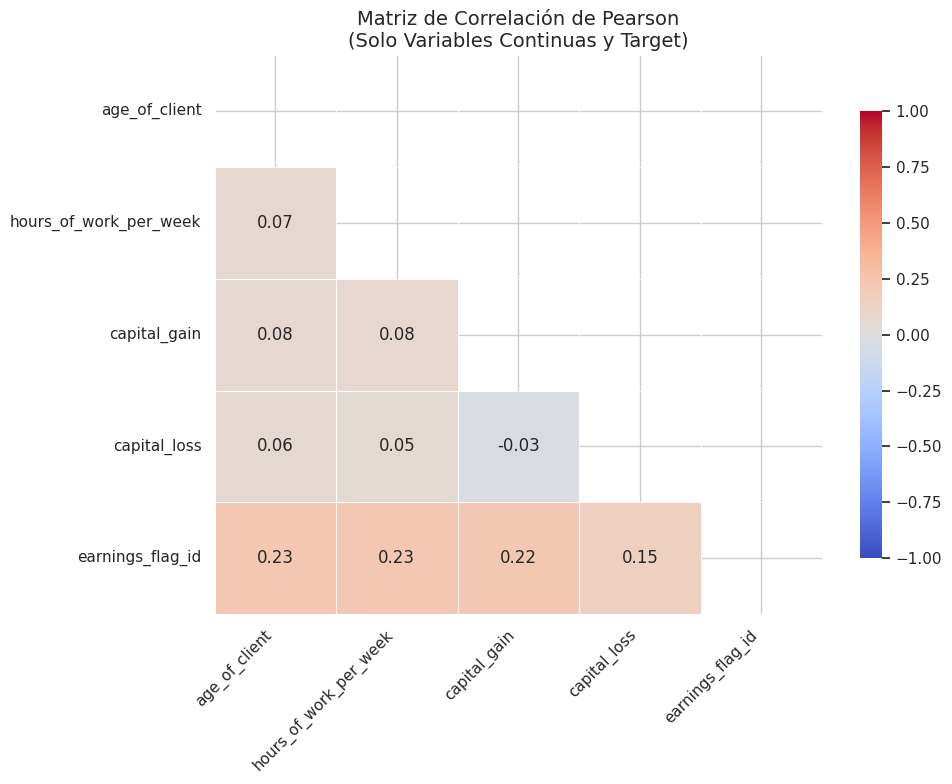

In [ ]:
# Correlaciones numericas

cols_numericas_reales = [
    'age_of_client',
    'hours_of_work_per_week',
    'capital_gain',
    'capital_loss',
    'earnings_flag_id' # 0 o 1
]

# Calculamos la matriz de correlación
matriz_corr = df_data_explor[cols_numericas_reales].corr()
plt.figure(figsize=(10, 8))

# nos interesa solo la mitad
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm', # azul (negativo), rojo (positivo)
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación de Pearson\n(Solo Variables Continuas y Target)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Composicion de los datos y metricas sencillas

# Matriz de dispersion


In [ ]:
# Analisis de varianzas (Tabla ANOVA)

In [ ]:
# PCA

Multiples variables categoricas, modelo de decision binario

In [ ]:
# Regresion logistica
# Regresion multiple (categorica)
# Random forests
#
#